# Hierarchical and Grouped Forecasting

Lesson 19 built *hierarchical* and *grouped* structures with `aggregate()`.

Here we produce *coherent* forecasts for those structures:

1. Fit a model at **every** series (all levels) → *base* forecasts (often incoherent).
2. *Reconcile* them so children add up to parents → *coherent* forecasts.
3. Evaluate point accuracy (and later, distributional accuracy).

**Reconciliation methods we use:**

- *BottomUp* — forecast only the bottom series, sum upward (ignores upper-level signal).
- *MinTrace(ols)* — least-squares reconciliation; treats all levels equally.
- *MinTrace(mint_shrink)* — uses residual covariances (shrunk) so noisier series get less weight.

Companion structure notebook: `19_hierarchical_and_grouped.ipynb`.

## Setup

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

import warnings

warnings.filterwarnings("ignore")

# Nixtla long-format: keep unique_id as a column (not the index)
os.environ["NIXTLA_ID_AS_COL"] = "true"

LESSON_DIR = Path().resolve()
COURSE_DIR = LESSON_DIR.parent
DATA_DIR = COURSE_DIR / "data"

if str(COURSE_DIR) not in sys.path:
    sys.path.insert(0, str(COURSE_DIR))

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoets.html
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

# https://nixtlaverse.nixtla.io/hierarchicalforecast/
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.evaluation import evaluate
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.utils import aggregate

# https://nixtlaverse.nixtla.io/utilsforecast/losses.html
from utilsforecast.losses import rmse, mase, mqloss

# https://nixtlaverse.nixtla.io/utilsforecast/plotting.html
from utilsforecast.plotting import plot_series

# https://seaborn.pydata.org/
sns.set_theme(style="whitegrid")

from utils import load_tourism

In [3]:
def rename_models(df, labels):
    """Apply at most one string replacement to each column name.

    Reconciled columns look like ``AutoETS/MinTrace_method-mint_shrink``;
    short labels keep legends readable.
    """
    return df.rename(
        columns=lambda c: next(
            (c.replace(k, v) for k, v in labels.items() if k in c),
            c,
        )
    )

## Forecasting Australian domestic tourism

We forecast overnight trips with a *mixed* geo × purpose structure.

**Workflow:**

1. Bottom-level series → `aggregate(spec=...)` → all levels in `Y_df`
2. Hold out 2016–2017 (8 quarters) as the test set
3. Fit `AutoETS` at every series → base forecasts
4. Reconcile with BottomUp, OLS, and MinT
5. Evaluate RMSE / MASE by aggregation level

### Load and reshape tourism

In [4]:
state_abbrev = {
    "Australian Capital Territory": "ACT",
    "New South Wales": "NSW",
    "Northern Territory": "NT",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Tasmania": "TAS",
    "Victoria": "VIC",
    "Western Australia": "WA",
}

tourism = load_tourism().reset_index()

aus_tourism = tourism.assign(
    Country="Australia",
    State=lambda x: x["State"].replace(state_abbrev),
    ds=lambda x: x["Quarter"].dt.to_timestamp(),
    y=lambda x: x["Trips"],
)[["Country", "State", "Region", "Purpose", "ds", "y"]]

display(aus_tourism.head())

,Country,State,Region,Purpose,ds,y
0,Australia,SA,Adelaide,Business,1998-01-01,135.077690
1,Australia,SA,Adelaide,Business,1998-04-01,109.987316
2,Australia,SA,Adelaide,Business,1998-07-01,166.034687
3,Australia,SA,Adelaide,Business,1998-10-01,127.160464
4,Australia,SA,Adelaide,Business,1999-01-01,137.448533


### Aggregate, split, forecast, reconcile

**Try changing parameters:**

- Drop a level from `spec` → fewer series; faster fit; coarser evaluation tags.
- `h=8` matches the 8-quarter test window; a longer `h` without more test data is not useful here.
- `fitted=True` stores in-sample fits → residuals for MinTrace covariance estimation.
- Swap `mint_shrink` for `ols` alone → ignores relative residual scales.

In [5]:
# Mixed structure: nested geography crossed with Purpose
tourism_spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "Purpose"],
    ["Country", "State", "Region"],
    ["Country", "State", "Purpose"],
    ["Country", "State", "Region", "Purpose"],
]

Y_df, S_df, tags = aggregate(
    df=aus_tourism,
    spec=tourism_spec,
)

# Hold out final two years (8 quarters)
Y_train_df = Y_df.loc[Y_df["ds"] < "2016"]
Y_test_df = Y_df.loc[Y_df["ds"] >= "2016"]

print(
    f"Series: {Y_df['unique_id'].nunique()}  |  "
    f"train rows: {len(Y_train_df):,}  |  test rows: {len(Y_test_df):,}"
)

Series: 425  |  train rows: 30,600  |  test rows: 3,400


In [6]:
# Base forecasts at every level (season_length=4 → quarterly seasonality)
sf = StatsForecast(
    models=[AutoETS(season_length=4)],
    freq="QS",
    n_jobs=-1,
)

# fitted=True is required so MinTrace can estimate residual covariances
Y_hat_df = sf.forecast(
    h=8,
    df=Y_train_df,
    fitted=True,
)
Y_fitted_df = sf.forecast_fitted_values()

reconcilers = [
    BottomUp(),
    # OLS: equal weight on all levels
    MinTrace(method="ols"),
    # mint_shrink: shrink residual covariance (more weight on reliable levels)
    MinTrace(method="mint_shrink"),
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers)
Y_rec_df = hrec.reconcile(
    Y_hat_df=Y_hat_df,
    Y_df=Y_fitted_df,
    S_df=S_df,
    tags=tags,
)

tourism_renames = {
    "AutoETS/MinTrace_method-mint_shrink": "MinT",
    "AutoETS/MinTrace_method-ols": "OLS",
    "AutoETS/BottomUp": "BottomUp",
    "AutoETS": "Base",
}
Y_rec_df = rename_models(Y_rec_df, tourism_renames)

display(Y_rec_df.head())

,unique_id,ds,Base,BottomUp,OLS,MinT
0,Australia,2016-01-01,26293.731209,24681.663762,26179.227026,25668.806779
1,Australia,2016-04-01,24465.684711,22949.801904,24371.211278,23982.055297
2,Australia,2016-07-01,23870.122954,22418.484671,23776.918680,23462.684029
3,Australia,2016-10-01,24591.404841,23058.257520,24503.914009,24157.092110
4,Australia,2017-01-01,26293.731209,24801.654393,26192.617120,25833.968989


### Forecast plots: national and states

History from 2011 onward (recent context only). Point forecasts — no intervals yet.

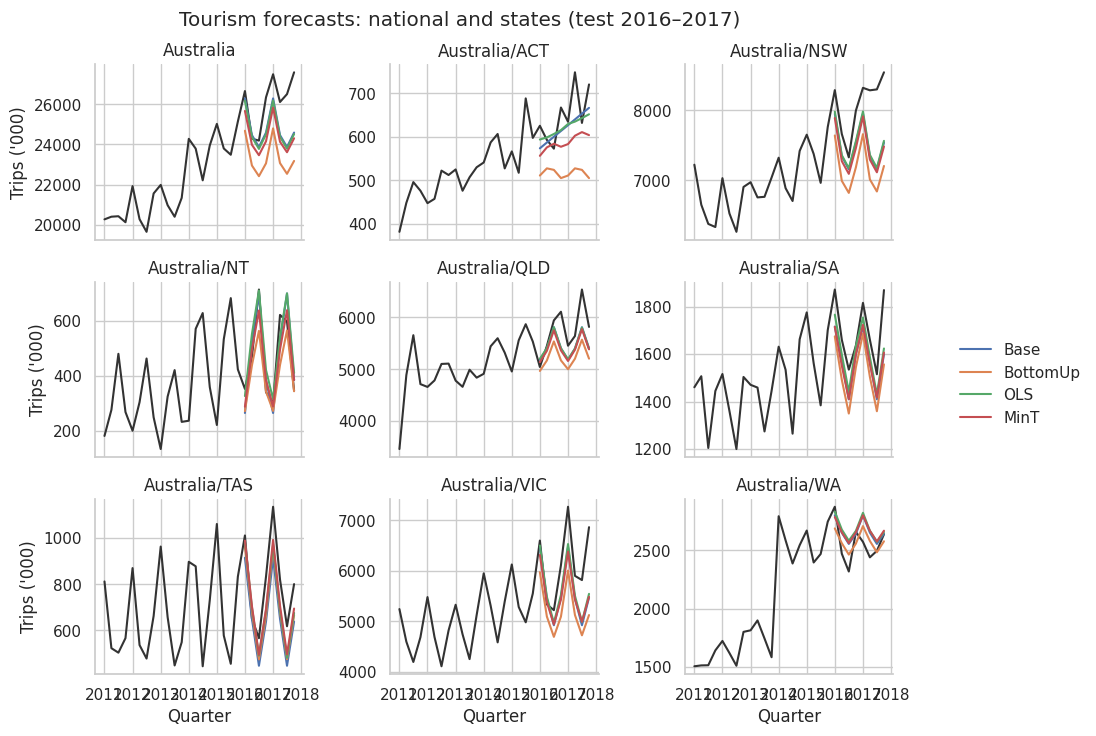

In [7]:
plot_ids = [*tags["Country"], *tags["Country/State"]]
model_cols = ["Base", "BottomUp", "OLS", "MinT"]

hist = Y_df.loc[
    Y_df["unique_id"].isin(plot_ids) & (Y_df["ds"] >= "2011")
]
fcst = Y_rec_df.loc[Y_rec_df["unique_id"].isin(plot_ids)]

plot_long = fcst.melt(
    id_vars=["unique_id", "ds"],
    value_vars=model_cols,
    var_name="model",
    value_name="forecast",
)

g = sns.FacetGrid(
    data=hist,
    col="unique_id",
    col_wrap=3,
    sharey=False,
    height=2.4,
    aspect=1.3,
)
g.map_dataframe(sns.lineplot, x="ds", y="y", color="0.2", label="Actual")

for ax, uid in zip(g.axes.flat, g.col_names):
    uid_fcst = plot_long.loc[plot_long["unique_id"] == uid]
    sns.lineplot(
        data=uid_fcst,
        x="ds",
        y="forecast",
        hue="model",
        ax=ax,
        legend=False,
    )
    ax.set_title(uid)

g.set_axis_labels("Quarter", "Trips ('000)")
g.fig.suptitle("Tourism forecasts: national and states (test 2016–2017)", y=1.02)

# One shared legend from the last facet's forecast lines
handles, labels = g.axes.flat[-1].get_legend_handles_labels()
# Rebuild legend from model hues on a representative panel
sample = plot_long.loc[plot_long["unique_id"] == plot_ids[0]]
fig_leg, ax_leg = plt.subplots()
sns.lineplot(data=sample, x="ds", y="forecast", hue="model", ax=ax_leg)
handles, labels = ax_leg.get_legend_handles_labels()
plt.close(fig_leg)
g.fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()

### Forecast plots: by purpose of travel

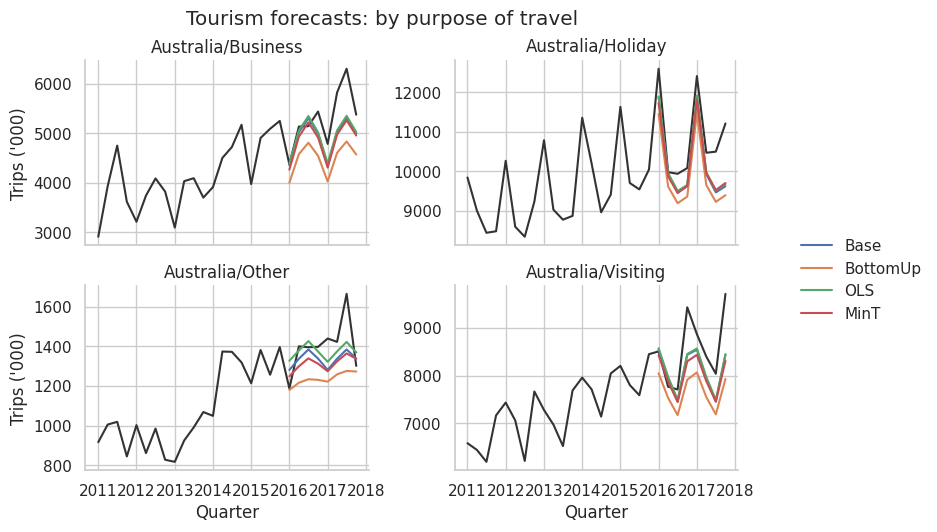

In [8]:
purpose_ids = list(tags["Country/Purpose"])

hist_p = Y_df.loc[
    Y_df["unique_id"].isin(purpose_ids) & (Y_df["ds"] >= "2011")
]
fcst_p = Y_rec_df.loc[Y_rec_df["unique_id"].isin(purpose_ids)]
plot_long_p = fcst_p.melt(
    id_vars=["unique_id", "ds"],
    value_vars=model_cols,
    var_name="model",
    value_name="forecast",
)

g = sns.FacetGrid(
    data=hist_p,
    col="unique_id",
    col_wrap=2,
    sharey=False,
    height=2.6,
    aspect=1.5,
)
g.map_dataframe(sns.lineplot, x="ds", y="y", color="0.2")

for ax, uid in zip(g.axes.flat, g.col_names):
    uid_fcst = plot_long_p.loc[plot_long_p["unique_id"] == uid]
    sns.lineplot(
        data=uid_fcst,
        x="ds",
        y="forecast",
        hue="model",
        ax=ax,
        legend=False,
    )
    ax.set_title(uid)

g.set_axis_labels("Quarter", "Trips ('000)")
g.fig.suptitle("Tourism forecasts: by purpose of travel", y=1.02)

sample = plot_long_p.loc[plot_long_p["unique_id"] == purpose_ids[0]]
fig_leg, ax_leg = plt.subplots()
sns.lineplot(data=sample, x="ds", y="forecast", hue="model", ax=ax_leg)
handles, labels = ax_leg.get_legend_handles_labels()
plt.close(fig_leg)
g.fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()

### Accuracy by level (RMSE and MASE)

- *RMSE* grows toward the top of the hierarchy (larger scale) — compare **within** a level.
- *MASE* is scale-free — better for comparing methods across levels.
- Reconciliation (OLS / MinT) typically beats BottomUp by using information from all levels.

In [9]:
eval_tags = {
    "Total": tags["Country"],
    "Purpose": tags["Country/Purpose"],
    "State": tags["Country/State"],
    "Regions": tags["Country/State/Region"],
    "Bottom": tags["Country/State/Region/Purpose"],
}

eval_df = Y_rec_df.merge(Y_test_df, on=["unique_id", "ds"])
evaluation = evaluate(
    df=eval_df,
    tags=eval_tags,
    train_df=Y_train_df,
    metrics=[rmse, partial(mase, seasonality=4)],
)

model_names = ["Base", "BottomUp", "MinT", "OLS"]
evaluation_table = (
    evaluation.pivot_table(
        index="level",
        columns="metric",
        values=model_names,
        sort=False,
    )
    .rename(index={"Overall": "All series"})
    .reorder_levels([1, 0], axis="columns")
    .sort_index(axis="columns")
    .rename(columns={"mase": "MASE", "rmse": "RMSE"})
)

display(evaluation_table.round(2))

metric      MASE                          RMSE                           
            Base BottomUp  MinT   OLS     Base BottomUp     MinT      OLS
level                                                                    
Total       1.53     3.09  1.93  1.60  1713.15  2988.73  2008.69  1780.35
Purpose     1.30     2.17  1.41  1.22   524.21   784.32   552.68   501.59
State       1.31     1.85  1.32  1.19   298.42   407.30   305.92   284.18
Regions     1.11     1.18  0.99  0.99    50.84    54.31    45.53    45.91
Bottom      0.99     0.99  0.94  1.02    19.31    19.31    17.63    18.16
All series  1.02     1.06  0.96  1.02    40.54    49.32    39.41    38.35

## Reconciled distributional forecasts

So far we reconciled *point* forecasts. Prediction intervals need reconciled *distributions*.

Two practical options in `reconcile(..., intervals_method=...)`:

1. **`normality`** (default) — if base forecasts are ~Normal, reconciled forecasts stay Normal with covariance $S G \hat\Sigma G' S'$. Cheap and fast.
2. **`bootstrap`** — simulate sample paths from the base models, reconcile each path, then take percentiles. Use when normality is dubious; more expensive.

**Try changing:**

- `level=[80, 90]` → which interval widths are returned as columns (`lo-90`, `hi-90`, …).
- `intervals_method="bootstrap"` → slower; intervals need not be symmetric.

In [10]:
# Re-forecast tourism with prediction levels for the distributional demo
pi_levels = [80, 90]

Y_hat_pi = sf.forecast(
    h=8,
    df=Y_train_df,
    fitted=True,
    level=pi_levels,
)
Y_fitted_pi = sf.forecast_fitted_values()

# Keep one reconciler so column names stay simple for the comparison plot
hrec_mint = HierarchicalReconciliation(
    reconcilers=[MinTrace(method="mint_shrink")]
)

Y_rec_norm = hrec_mint.reconcile(
    Y_hat_df=Y_hat_pi,
    Y_df=Y_fitted_pi,
    S_df=S_df,
    tags=tags,
    level=pi_levels,
    intervals_method="normality",
)

Y_rec_boot = hrec_mint.reconcile(
    Y_hat_df=Y_hat_pi,
    Y_df=Y_fitted_pi,
    S_df=S_df,
    tags=tags,
    level=pi_levels,
    intervals_method="bootstrap",
)

print("Normality columns (sample):", list(Y_rec_norm.columns)[:8])
print("Bootstrap columns (sample):", list(Y_rec_boot.columns)[:8])

Normality columns (sample): ['unique_id', 'ds', 'AutoETS', 'AutoETS-lo-90', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-90', 'AutoETS/MinTrace_method-mint_shrink']
Bootstrap columns (sample): ['unique_id', 'ds', 'AutoETS', 'AutoETS-lo-90', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-90', 'AutoETS/MinTrace_method-mint_shrink']


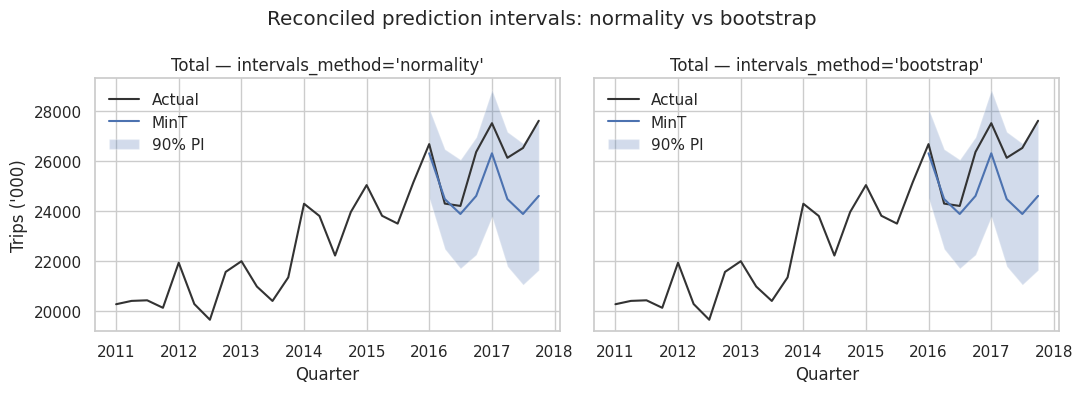

In [11]:
# Compare 90% intervals for the national total under both methods
total_id = tags["Country"][0]
hist_total = Y_df.loc[
    (Y_df["unique_id"] == total_id) & (Y_df["ds"] >= "2011")
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4), sharey=True)

for ax, (label, rec_df) in zip(
    axes,
    [("normality", Y_rec_norm), ("bootstrap", Y_rec_boot)],
):
    # After MinTrace, point + interval columns include the method name
    point_col = [c for c in rec_df.columns if c.startswith("AutoETS") and "-lo" not in c and "-hi" not in c][0]
    lo_col = [c for c in rec_df.columns if c.endswith("-lo-90")][0]
    hi_col = [c for c in rec_df.columns if c.endswith("-hi-90")][0]

    fcst = rec_df.loc[rec_df["unique_id"] == total_id]

    sns.lineplot(data=hist_total, x="ds", y="y", ax=ax, color="0.2", label="Actual")
    sns.lineplot(data=fcst, x="ds", y=point_col, ax=ax, label="MinT")
    ax.fill_between(
        fcst["ds"],
        fcst[lo_col],
        fcst[hi_col],
        alpha=0.25,
        label="90% PI",
    )
    ax.set_title(f"Total — intervals_method={label!r}")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Trips ('000)")
    ax.legend(frameon=False)

fig.suptitle("Reconciled prediction intervals: normality vs bootstrap")
fig.tight_layout()
plt.show()

## Forecasting Australian prison population

Grouped structure (crossed factors). We compare:

- Base `AutoETS` (forced `MAM` — multiplicative error / additive trend / multiplicative seasonality, common for positive counts)
- BottomUp and MinT reconciliations
- `Naive` as a baseline for CRPS *skill scores*

Test set: 2015Q1–2016Q4 (8 quarters).

In [12]:
prison = (
    pd.read_csv(DATA_DIR / "prison.csv", index_col=0)
    .assign(
        ds=lambda x: pd.PeriodIndex(x["ds"], freq="Q").to_timestamp(),
        Country="Australia",
        # Scale to thousands for readable axes and loss magnitudes
        y=lambda x: x["y"] / 1e3,
    )
)

prison_spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "Gender"],
    ["Country", "Legal"],
    ["Country", "State", "Gender", "Legal"],
]

Y_prison, S_prison, tags_prison = aggregate(
    df=prison,
    spec=prison_spec,
)

Y_train_p = Y_prison.loc[Y_prison["ds"] < "2015"]
Y_test_p = Y_prison.loc[Y_prison["ds"] >= "2015"]

print(
    f"Series: {Y_prison['unique_id'].nunique()}  |  "
    f"train: {len(Y_train_p):,}  |  test: {len(Y_test_p):,}"
)

Series: 45  |  train: 1,800  |  test: 360


In [13]:
# Deciles 10..90 → many PI columns for CRPS / mqloss evaluation
levels = list(range(10, 100, 10))

sf_prison = StatsForecast(
    models=[
        AutoETS(season_length=4, model="MAM"),
        Naive(),
    ],
    freq="QS",
    n_jobs=-1,
)

Y_hat_p = sf_prison.forecast(
    h=8,
    df=Y_train_p,
    fitted=True,
    level=levels,
)
Y_fitted_p = sf_prison.forecast_fitted_values()

hrec_p = HierarchicalReconciliation(
    reconcilers=[
        BottomUp(),
        MinTrace(method="mint_shrink"),
    ]
)
Y_rec_p = hrec_p.reconcile(
    Y_hat_df=Y_hat_p,
    Y_df=Y_fitted_p,
    S_df=S_prison,
    tags=tags_prison,
    level=levels,
)

prison_renames = {
    "AutoETS/MinTrace_method-mint_shrink": "AutoETS/MinT",
    "AutoETS/BottomUp": "AutoETS/BottomUp",
    "AutoETS": "AutoETS/Base",
    "Naive/MinTrace_method-mint_shrink": "Naive/MinT",
    "Naive/BottomUp": "Naive/BottomUp",
    "Naive": "Naive/Base",
}
Y_rec_p = rename_models(Y_rec_p, prison_renames)
model_names_p = list(prison_renames.values())

display(Y_rec_p.head())

,unique_id,ds,AutoETS/Base,AutoETS/Base-lo-90,AutoETS/Base-lo-80,AutoETS/Base-lo-70,AutoETS/Base-lo-60,AutoETS/Base-lo-50,AutoETS/Base-lo-40,AutoETS/Base-lo-30,...,Naive/MinT-lo-10,Naive/MinT-hi-10,Naive/MinT-hi-20,Naive/MinT-hi-30,Naive/MinT-hi-40,Naive/MinT-hi-50,Naive/MinT-hi-60,Naive/MinT-hi-70,Naive/MinT-hi-80,Naive/MinT-hi-90
0,Australia,2015-01-01,34.745887,34.091793,34.236264,34.333738,34.411207,34.477669,34.537353,34.592660,...,34.565359,34.648641,34.690953,34.734685,34.780773,34.830509,34.885892,34.950447,35.031673,35.152062
1,Australia,2015-04-01,35.067966,34.413809,34.558294,34.655777,34.733254,34.799722,34.859412,34.914724,...,34.548111,34.665889,34.725727,34.787574,34.852752,34.923089,35.001412,35.092708,35.207579,35.377834
2,Australia,2015-07-01,34.986896,33.530709,33.852340,34.069343,34.241810,34.389771,34.522645,34.645772,...,34.534876,34.679124,34.752410,34.828157,34.907983,34.994128,35.090055,35.201868,35.342556,35.551076
3,Australia,2015-10-01,35.629195,33.678304,34.109201,34.399925,34.630984,34.829211,35.007226,35.172183,...,34.523718,34.690282,34.774905,34.862371,34.954546,35.054017,35.164783,35.293895,35.456347,35.697125
4,Australia,2016-01-01,35.705412,33.754442,34.185357,34.476093,34.707160,34.905396,35.083417,35.248381,...,34.513888,34.700112,34.794724,34.892513,34.995568,35.106780,35.230621,35.374972,35.556598,35.825796


### Total prison population (with 90% intervals)

MinT often pulls the top-level forecast toward the test trend and tightens intervals relative to incoherent base forecasts.

In [14]:
fig = plot_series(
    df=Y_prison,
    forecasts_df=Y_rec_p,
    ids=list(tags_prison["Country"]),
    models=["AutoETS/Base", "AutoETS/BottomUp", "AutoETS/MinT"],
    level=[90],
    max_insample_length=20,
    engine="matplotlib",
)
fig.suptitle("Prison population (total)")
fig.supylabel("Number of prisoners ('000)")
plt.show()

### By state, legal status, and gender

Base vs MinT only (cleaner panels). Watch for shocks in the test window that no model anticipates (e.g. NSW / TAS surges).

In [15]:
fig = plot_series(
    df=Y_prison,
    forecasts_df=Y_rec_p,
    ids=list(tags_prison["Country/State"]),
    models=["AutoETS/Base", "AutoETS/MinT"],
    level=[90],
    max_insample_length=20,
    plot_random=False,
    max_ids=8,
    engine="matplotlib",
)
fig.suptitle("Prison population by state")
fig.supylabel("Number of prisoners ('000)")
plt.show()

In [16]:
fig = plot_series(
    df=Y_prison,
    forecasts_df=Y_rec_p,
    ids=list(tags_prison["Country/Legal"]),
    models=["AutoETS/Base", "AutoETS/MinT"],
    level=[90],
    max_insample_length=20,
    plot_random=False,
    engine="matplotlib",
)
fig.suptitle("Prison population by legal status")
fig.supylabel("Number of prisoners ('000)")
plt.show()

In [17]:
fig = plot_series(
    df=Y_prison,
    forecasts_df=Y_rec_p,
    ids=list(tags_prison["Country/Gender"]),
    models=["AutoETS/Base", "AutoETS/MinT"],
    level=[90],
    max_insample_length=20,
    plot_random=False,
    engine="matplotlib",
)
fig.suptitle("Prison population by gender")
fig.supylabel("Number of prisoners ('000)")
plt.show()

### Selected bottom-level series (large states)

Remand growth in the test period is often missed; NSW sentenced males also jump — both matter for national totals.

In [18]:
bottom_ids = [
    uid
    for uid in tags_prison["Country/State/Gender/Legal"]
    if uid.split("/")[1] in {"NSW", "QLD", "VIC", "WA"}
]

fig = plot_series(
    df=Y_prison,
    forecasts_df=Y_rec_p,
    ids=bottom_ids,
    models=["AutoETS/Base", "AutoETS/MinT"],
    level=[90],
    max_insample_length=20,
    plot_random=False,
    max_ids=16,
    engine="matplotlib",
)
fig.suptitle("Bottom-level series: large states × gender × legal")
fig.supylabel("Number of prisoners ('000)")
plt.show()

### Accuracy: MASE and CRPS skill score

- *MASE* — scaled point accuracy (lower is better).
- *CRPS skill score* vs Naive — $100 \times (\mathrm{CRPS}_{\mathrm{Naive}} - \mathrm{CRPS}_{\mathrm{ETS}}) / \mathrm{CRPS}_{\mathrm{Naive}}$ (higher is better).

We approximate CRPS via multi-quantile loss (`mqloss`) over the `level` grid.

In [19]:
eval_tags_p = {
    "Total": tags_prison["Country"],
    "State": tags_prison["Country/State"],
    "Legal status": tags_prison["Country/Legal"],
    "Gender": tags_prison["Country/Gender"],
    "Bottom": tags_prison["Country/State/Gender/Legal"],
}

eval_df_p = Y_rec_p.merge(Y_test_p, on=["unique_id", "ds"])
evaluation_p = evaluate(
    df=eval_df_p,
    tags=eval_tags_p,
    train_df=Y_train_p,
    metrics=[partial(mase, seasonality=4), mqloss],
    level=levels,
)

evaluation_wide = (
    evaluation_p.pivot_table(
        index="level",
        columns="metric",
        values=model_names_p,
        sort=False,
    )
    .rename(index={"Overall": "All series"})
    .reorder_levels([1, 0], axis="columns")
    .sort_index(axis="columns")
)

crps_ets = evaluation_wide["mqloss"].filter(like="AutoETS").to_numpy()
crps_naive = evaluation_wide["mqloss"].filter(like="Naive").to_numpy()
crps_skill_score = 100 * (crps_naive - crps_ets) / crps_naive

renames_final = {
    f"AutoETS/{name}": name
    for name in ("Base", "BottomUp", "MinT")
}
evaluation_final = (
    evaluation_wide.filter(like="AutoETS")
    .rename(columns={"mqloss": "Skill Score (CRPS)", "mase": "MASE"})
    .reorder_levels([1, 0], axis="columns")
    .sort_index(axis="columns")
    .rename(columns=renames_final)
    .reorder_levels([1, 0], axis="columns")
    .sort_index(axis="columns")
)
evaluation_final.loc[:, "Skill Score (CRPS)"] = crps_skill_score

display(evaluation_final.round(2))

metric        MASE                Skill Score (CRPS)                
              Base BottomUp  MinT               Base BottomUp   MinT
level                                                               
Total         1.64     1.51  1.54              43.91    47.86  47.31
State         1.67     1.64  1.67              25.71    26.53  25.79
Legal status  2.55     2.57  2.49              26.71    28.79  28.86
Gender        1.37     1.30  1.34              48.82    48.79  47.47
Bottom        2.11     2.11  2.10              14.55    14.55  14.88
All series    2.01     2.00  1.99              30.96    32.66  32.07

## Takeaways

- Fit base models at **all** levels, then *reconcile* for coherence.
- *BottomUp* is simple but discards upper-level information.
- *MinTrace* (OLS / mint_shrink) usually improves accuracy by combining all levels.
- For intervals: `intervals_method="normality"` is fast; `"bootstrap"` is more flexible.
- Evaluate **by level** (and with scale-free metrics) before declaring a winner.